# Initialisation

In [7]:
%reload_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from tqdm import tqdm
from scipy.interpolate import RectBivariateSpline
from matplotlib.colors import LogNorm

from oscillations import *

In [2]:
axis_size=15
legend_size=13
tick_size=13

plt.rc('axes',labelsize=axis_size)
plt.rc('legend',fontsize=legend_size)
plt.rc('xtick',labelsize=tick_size)
plt.rc('ytick',labelsize=tick_size)
plt.rc('font',size=legend_size)
plt.rc("figure", figsize=(8, 6))

plt.rcParams["text.usetex"] = True
plt.rcParams["font.family"] = "serif"

# Accelerator Neutrinos

## Oscillation probabilities

In [48]:
E = np.linspace(0.1,2,1000)*u.GeV
L = 295*u.km
rho = 3.3*u.g/u.cm**3 # Earth's density along T2K baseline
Z_over_A = 0.4


osc = OscillationParameters()
const = Constants()

Delta = [-np.pi/2, 0, np.pi/2, np.pi]
Delta_label = [r"$-\pi/2$", r"0", r"$\pi/2$", r"$\pi$"]
MH = [1, -1]
MH_label = ["Normal", "Inverted"]

psi0 = np.array([0., 1., 0.]) # start with muon neutrino

p_mu_e = np.zeros((len(MH), len(Delta), len(E)))
p_mu_e_anti = np.zeros((len(MH), len(Delta), len(E)))

for i, mh in enumerate(MH):
    osc.hierarchy = mh

    for j, delta in enumerate(Delta):
        osc.deltaCP = delta


        for k, e in enumerate(tqdm(E)):

            p_mu_e[i,j,k] = np.abs(proba_amp(L, e, rho, Z_over_A, osc, const, psi0, anti=False)[0])**2
            p_mu_e_anti[i,j,k] = np.abs(proba_amp(L, e, rho, Z_over_A, osc, const, psi0, anti=True)[0])**2

100%|██████████| 1000/1000 [00:00<00:00, 1285.57it/s]


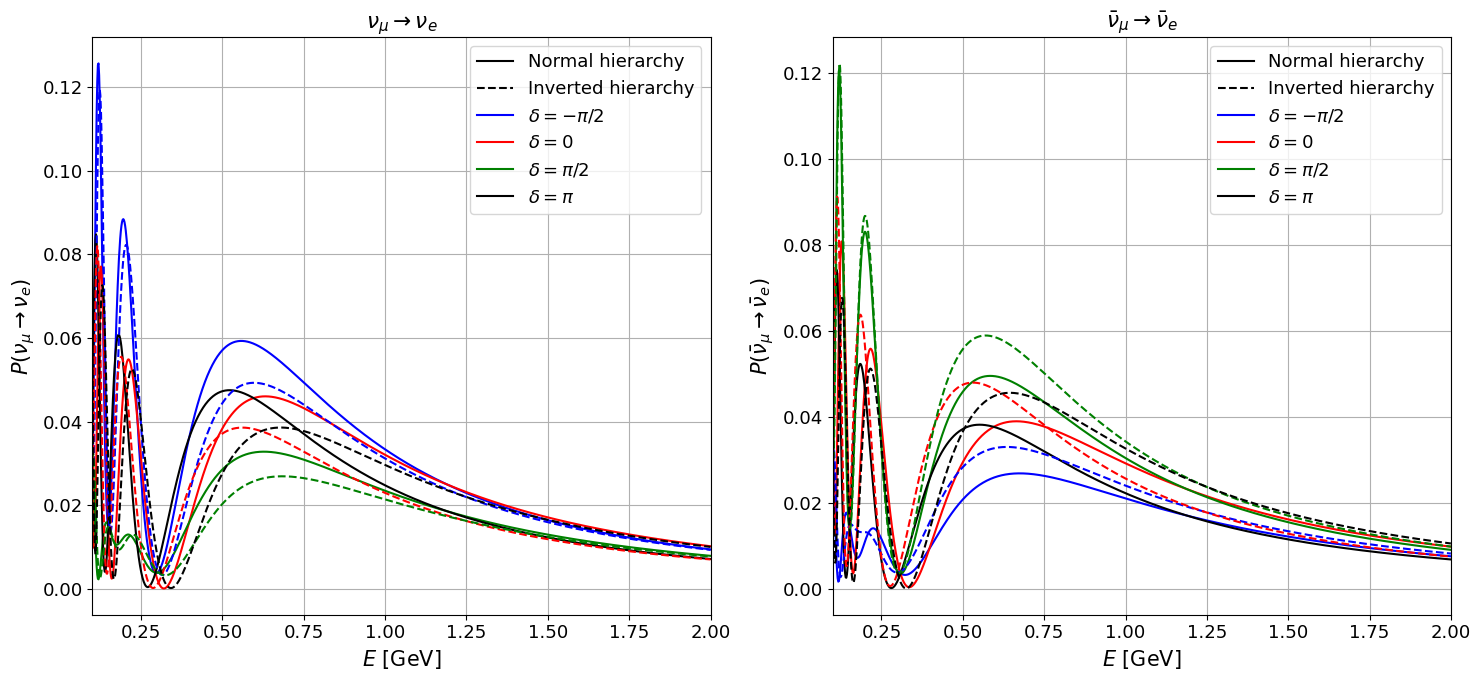

In [49]:
fig = plt.figure(figsize=(15,7))

plt.subplot(121)

ls = ['-', '--']
colors = ['b', 'r', 'g', 'k']

for i, mh in enumerate(MH):
    for j, delta in enumerate(Delta):
        plt.plot(E, p_mu_e[i,j], ls=ls[i], color=colors[j])



for i, mh_label in enumerate(MH_label):
    plt.plot([], [], ls=ls[i], color='k', label=f'{mh_label} hierarchy')

for i, delta_label in enumerate(Delta_label):
    plt.plot([], [], ls='-', color=colors[i], label=r'$\delta =$' + delta_label)


plt.xlim([E[0].value, E[-1].value])
plt.xlabel(r'$E$ [GeV]')
plt.ylabel(r'$P(\nu_\mu \rightarrow \nu_e)$')
plt.title(r'$\nu_\mu \rightarrow \nu_e$')
plt.legend()
plt.grid()

plt.subplot(122)

for i, mh in enumerate(MH):
    for j, delta in enumerate(Delta):
        plt.plot(E, p_mu_e_anti[i,j], ls=ls[i], color=colors[j])


for i, mh_label in enumerate(MH_label):
    plt.plot([], [], ls=ls[i], color='k', label=f'{mh_label} hierarchy')

for i, delta_label in enumerate(Delta_label):
    plt.plot([], [], ls='-', color=colors[i], label=r'$\delta =$' + delta_label)

plt.xlim([E[0].value, E[-1].value])
plt.xlabel(r'$E$ [GeV]')
plt.ylabel(r'$P(\bar{\nu}_\mu \rightarrow \bar{\nu}_e)$')
plt.title(r'$\bar{\nu}_\mu \rightarrow \bar{\nu}_e$')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

## Degeneracy

In [3]:
L = 295*u.km
E = 600*u.MeV

osc = OscillationParameters()
const = Constants()
rho = 3.3*u.g/u.cm**3
Z_over_A = 0.4

psi0 = np.array([0, 1, 0])

Delta = np.linspace(-np.pi, np.pi, 100)

p_mu_e = {'NH': np.zeros(len(Delta)), 'IH': np.zeros(len(Delta)), 'anti_NH': np.zeros(len(Delta)), 'anti_IH': np.zeros(len(Delta))}

for i, delta in tqdm(enumerate(Delta)) :

    # Normal Hierarchy
    osc.hierarchy = 1
    osc.deltaCP = delta
    p_mu_e['NH'][i] = np.abs(proba_amp(L, E, rho, Z_over_A, osc, const, psi0, anti=False)[0])**2
    p_mu_e['anti_NH'][i] = np.abs(proba_amp(L, E, rho, Z_over_A, osc, const, psi0, anti=True)[0])**2

    # Inverted Hierarchy
    osc.hierarchy = -1
    osc.deltaCP = delta
    p_mu_e['IH'][i] = np.abs(proba_amp(L, E, rho, Z_over_A, osc, const, psi0, anti=False)[0])**2
    p_mu_e['anti_IH'][i] = np.abs(proba_amp(L, E, rho, Z_over_A, osc, const, psi0, anti=True)[0])**2



100it [00:00, 536.97it/s]


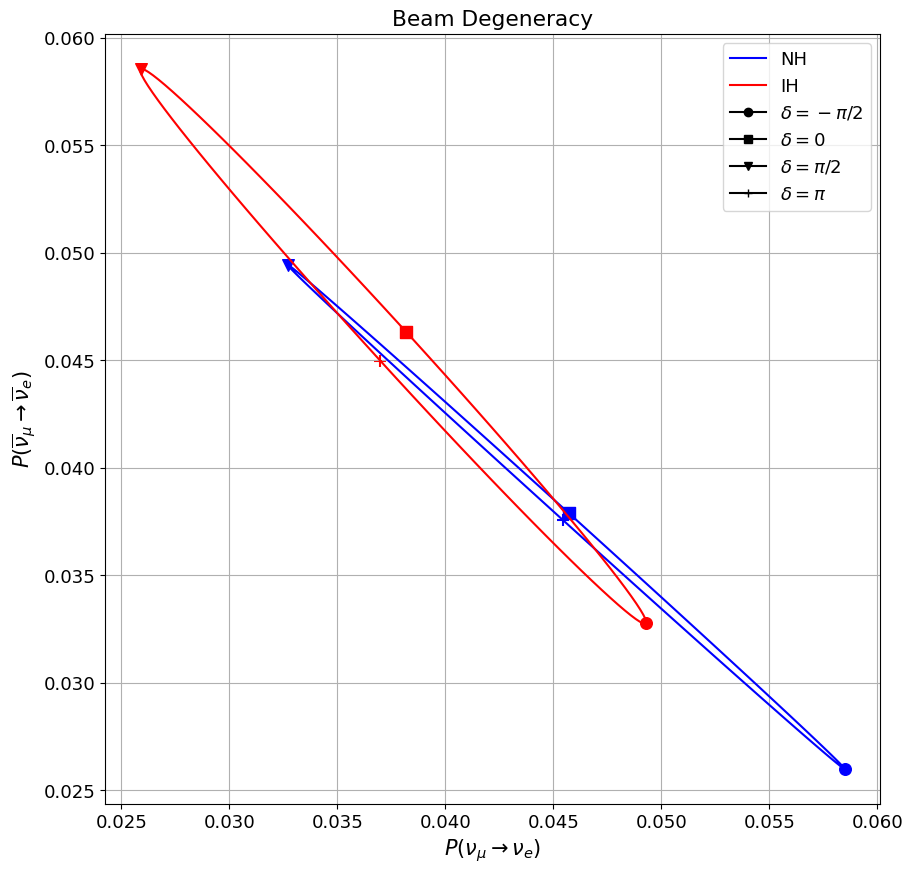

In [5]:
plt.figure(figsize=(10, 10))

plt.plot(p_mu_e['NH'], p_mu_e['anti_NH'], label='NH', color='b')
plt.plot(p_mu_e['IH'], p_mu_e['anti_IH'], label='IH', color='r')

# interpolate special delta values

delta_CP = np.array([-np.pi/2, 0, np.pi/2, np.pi])
delta_label = [r"-\pi/2", r"0", r"\pi/2", r"\pi"]
markers = ['o', 's', 'v', '+']

for delta, marker in zip(delta_CP, markers) :
    for mh, anti_mh, color in zip(['NH', 'IH'], ['anti_NH', 'anti_IH'], ['blue', 'red']) :

        p_mu_e_interp = np.interp(delta, Delta, p_mu_e[mh])
        p_mu_e_anti_interp = np.interp(delta, Delta, p_mu_e[anti_mh])
        plt.scatter(p_mu_e_interp, p_mu_e_anti_interp, marker=marker, color=color, s=70)

for marker, label in zip(markers, delta_label) :
    plt.plot([], [], color='k', marker=marker, label=r"$\delta = " + label + r"$")


plt.xlabel(r'$P(\nu_\mu \rightarrow \nu_e)$')
plt.ylabel(r'$P(\overline{\nu}_\mu \rightarrow \overline{\nu}_e)$')
plt.legend()
plt.title("Beam Degeneracy")
plt.grid()

plt.savefig('beam_degeneracy.png')
plt.show()

# Atmospherics

In [3]:
# the different layers of the earth

layers = {'Atmosphere': {'Rmin': 6371, 'Rmax': 6371+500, 'Density': 0*u.g/u.cm**3, 'Z/A': 0.4, 'Color': 'lightblue'},
          'Crust': {'Rmin': 5701, 'Rmax': 6371, 'Density': 3.3*u.g/u.cm**3, 'Z/A': 0.4, 'Color': 'green'},
          'Mantle': {'Rmin': 3480, 'Rmax': 5701, 'Density': 5.0*u.g/u.cm**3, 'Z/A': 0.4, 'Color': 'sienna'},
          'Outer Core': {'Rmin': 1220, 'Rmax': 3480, 'Density': 11.3*u.g/u.cm**3, 'Z/A': 0.4, 'Color': 'chocolate'},
          'Inner Core': {'Rmin': 0, 'Rmax': 1220, 'Density': 13.0*u.g/u.cm**3, 'Z/A': 0.4, 'Color': 'firebrick'}}

radii = [6371+500, 6371, 5701, 3480, 1220]
colors = ['lightblue', 'green', 'sienna', 'chocolate', 'firebrick']


osc = OscillationParameters()
const = Constants()


In [4]:
RSK = radii[1] - 1 # position of SK
XSK, YSK = 0, RSK
RP = (6371 + 15)  # production altitude of neutrinos in the atmosphere

Mantle discontinuity angle: 63.51 degrees
Outer Core discontinuity angle: 33.11 degrees
Inner Core discontinuity angle: 11.04 degrees


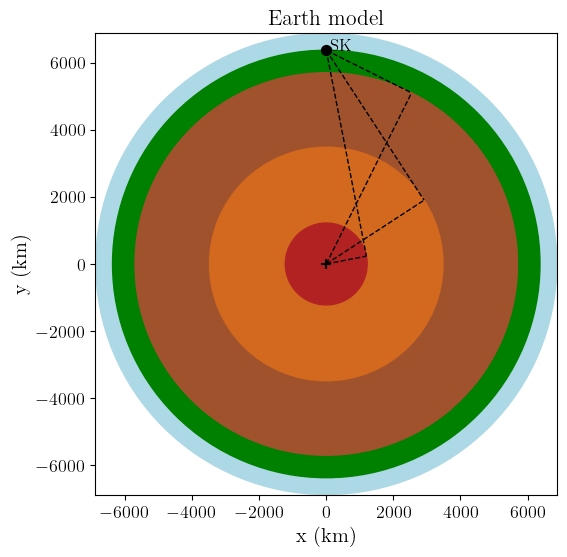

In [141]:
fig, ax = plt.subplots(figsize=(6,6))

circle1 = plt.Circle((0, 0), RSK, color='lightblue', zorder=0)
ax.add_artist(circle1)

for key, layer in layers.items() :

    circle = plt.Circle((0, 0), layer['Rmax'], color=layer['Color'], zorder=1)
    ax.add_artist(circle)

ax.scatter(XSK, YSK, color='k', s=50, zorder=2)
ax.text(XSK+100, YSK, 'SK', fontsize=12, zorder=3)
ax.scatter(0, 0, color='k', marker="+", s=50, zorder=2)

ax.set_xlim(-RP-500, RP+500)
ax.set_ylim(-RP-500, RP+500)
ax.set_aspect('equal', adjustable='box')
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.set_title('Earth model')

disc_angles = []

for layer_name, layer in layers.items(): 

    RL = layer["Rmax"]

    if RL > RSK :
        continue
    psi = np.arccos(RL/RSK)
    disc_angle = np.arcsin(RL/RSK)

    disc_angles.append(disc_angle)

    print(f"{layer_name} discontinuity angle: {disc_angle*180/np.pi:.2f} degrees")



    ax.plot([0, np.cos(np.pi/2 - psi)*RL], [RSK, np.sin(np.pi/2 - psi)*RL], color='k', ls='--', lw=1, zorder=1)
    ax.plot([0, np.cos(np.pi/2 - psi)*RL], [0, np.sin(np.pi/2 - psi)*RL], color='k', ls='--', lw=1, zorder=1)

disc_angles = np.array(disc_angles)
plt.show()


In [142]:
EE = np.logspace(-1, 2, 500)*u.GeV
Thetaz = np.linspace(0, np.pi, 500)

# Probas = {'NH': np.zeros((len(Thetaz), len(EE))), 'IH': np.zeros((len(Thetaz), len(EE))), 'anti_NH': np.zeros((len(Thetaz), len(EE))), 'anti_IH': np.zeros((len(Thetaz), len(EE)))}
# Proba = np.zeros((len(Thetaz), len(EE)))

# psi0 = np.array([0, 1, 0])


# for i, thetaz in tqdm(enumerate(Thetaz)) :
#     for j, E in enumerate(EE) :

#         osc.hierarchy = 1
#         Probas['NH'][i,j] = np.abs(proba_through_earth(thetaz, E, layers, radii, RP, RSK, psi0, osc, const, anti=False)[0])**2
#         Probas['anti_NH'][i,j] = np.abs(proba_through_earth(thetaz, E, layers, radii, RP, RSK, psi0, osc, const, anti=True)[0])**2

#         osc.hierarchy = -1
#         Probas['IH'][i,j] = np.abs(proba_through_earth(thetaz, E, layers, radii, RP, RSK, psi0, osc, const, anti=False)[0])**2
#         Probas['anti_IH'][i,j] = np.abs(proba_through_earth(thetaz, E, layers, radii, RP, RSK, psi0, osc, const, anti=True)[0])**2

        

In [143]:
# # interpolation

# interp_func_NH = RectBivariateSpline(Thetaz, EE, Probas['NH'])
# interp_func_IH = RectBivariateSpline(Thetaz, EE, Probas['IH'])
# interp_func_anti_NH = RectBivariateSpline(Thetaz, EE, Probas['anti_NH'])
# interp_func_anti_IH = RectBivariateSpline(Thetaz, EE, Probas['anti_IH'])

E_grid = np.logspace(np.log10(EE.value.min()), np.log10(EE.value.max()), 500)
Thetaz_grid = np.linspace(Thetaz.min(), Thetaz.max(), 500)

# Probas_NH = interp_func_NH(Thetaz_grid, E_grid)
# Probas_IH = interp_func_IH(Thetaz_grid, E_grid)
# Probas_anti_NH = interp_func_anti_NH(Thetaz_grid, E_grid)
# Probas_anti_IH = interp_func_anti_IH(Thetaz_grid, E_grid)

In [144]:
# np.save('probas_NH.npy', Probas_NH)
# np.save('probas_IH.npy', Probas_IH)
# np.save('probas_anti_NH.npy', Probas_anti_NH)
# np.save('probas_anti_IH.npy', Probas_anti_IH)

Probas_NH = np.load('probas_NH.npy')
Probas_IH = np.load('probas_IH.npy')
Probas_anti_NH = np.load('probas_anti_NH.npy')
Probas_anti_IH = np.load('probas_anti_IH.npy')

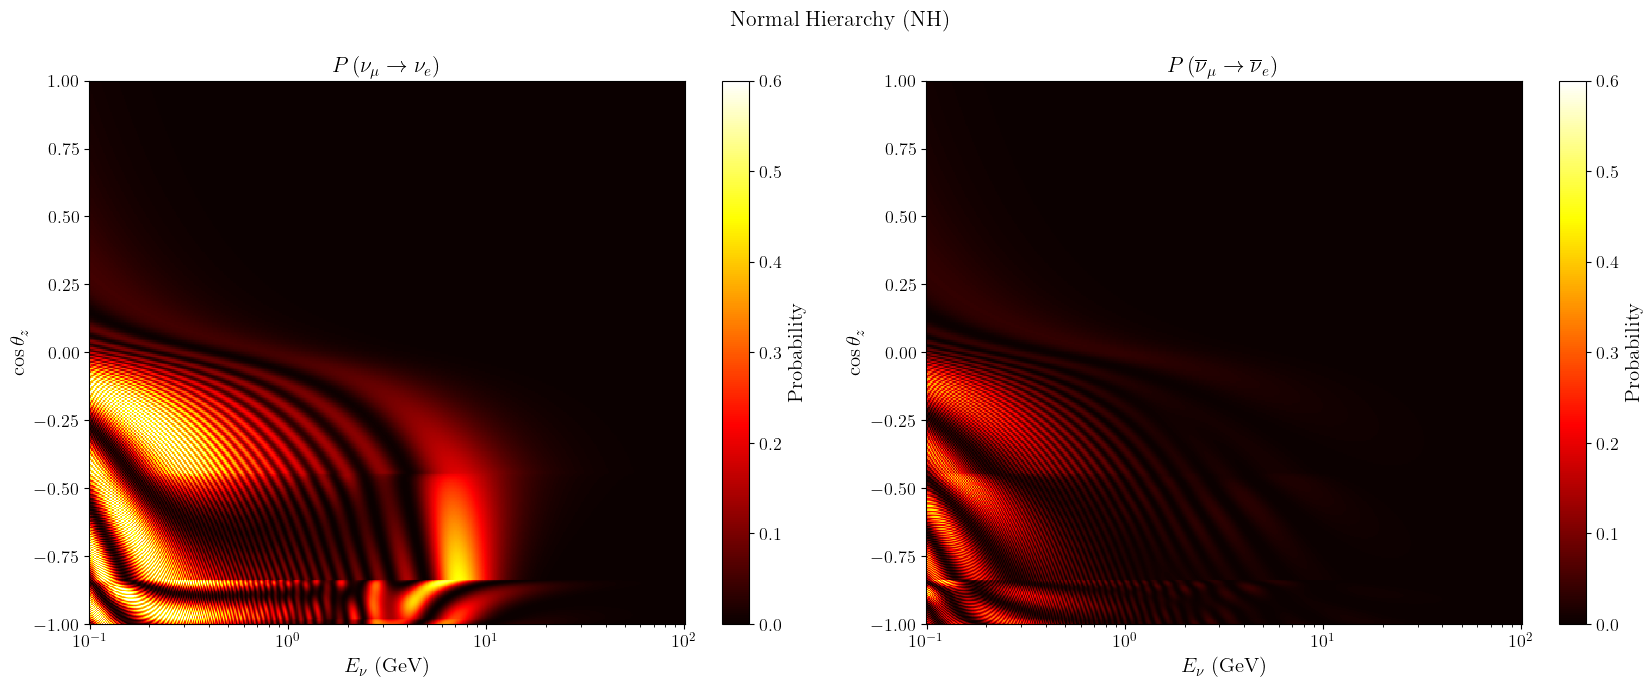

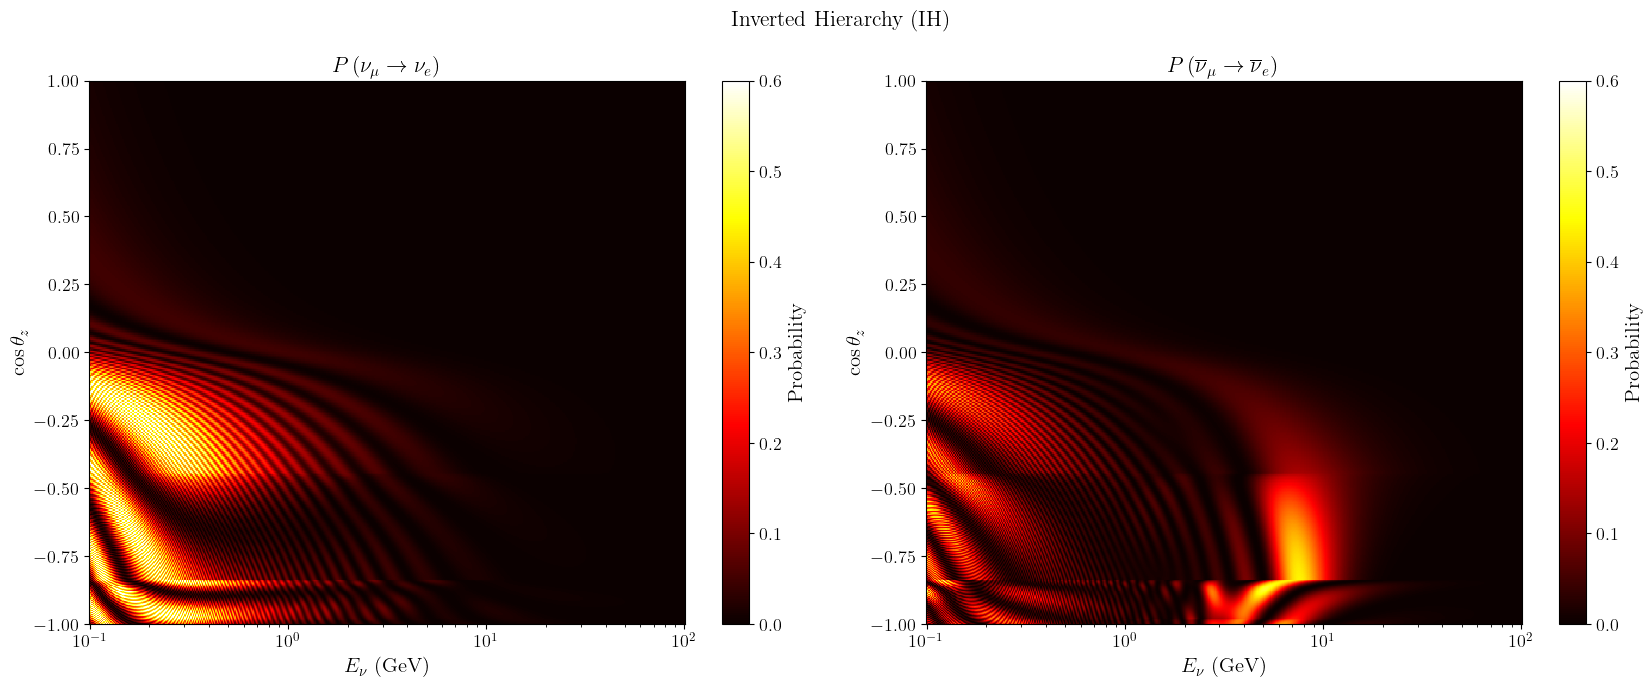

In [145]:
%matplotlib inline

plt.figure(figsize=(17, 7))

# Plot for Normal Hierarchy (NH)
plt.subplot(1, 2, 1)
plt.pcolormesh(E_grid, np.cos(Thetaz_grid), Probas_NH, cmap='hot', vmin=0, vmax=0.6, rasterized=True)
plt.title(r'$P\left(\nu_\mu \rightarrow \nu_e\right)$')
plt.xlabel(r'$E_\nu$ (GeV)')
plt.ylabel(r'$\cos\theta_z$')
plt.xscale('log')
plt.colorbar(label='Probability')

# Plot for Normal Hierarchy (NH) and antineutrinos
plt.subplot(1, 2, 2)
plt.pcolormesh(E_grid, np.cos(Thetaz_grid), Probas_anti_NH, cmap='hot', vmin=0, vmax=0.6, rasterized=True)
plt.title(r'$P\left(\overline{\nu}_\mu \rightarrow \overline{\nu}_e\right)$')
plt.xlabel(r'$E_\nu$ (GeV)')
plt.ylabel(r'$\cos\theta_z$')
plt.xscale('log')
plt.colorbar(label='Probability')

plt.suptitle('Normal Hierarchy (NH)')
plt.tight_layout()
plt.savefig('atm_prob_NH.pdf')


plt.figure(figsize=(17, 7))

# Plot for Inverted Hierarchy (IH)
plt.subplot(1, 2, 1)
plt.pcolormesh(E_grid, np.cos(Thetaz_grid), Probas_IH, cmap='hot', vmin=0, vmax=0.6, rasterized=True)
plt.title(r'$P\left(\nu_\mu \rightarrow \nu_e\right)$')
plt.xlabel(r'$E_\nu$ (GeV)')
plt.ylabel(r'$\cos\theta_z$')
plt.xscale('log')
plt.colorbar(label='Probability')

# Plot for Inverted Hierarchy (IH) and antineutrinos
plt.subplot(1, 2, 2)
plt.pcolormesh(E_grid, np.cos(Thetaz_grid), Probas_anti_IH, cmap='hot', vmin=0, vmax=0.6, rasterized=True)
plt.title(r'$P\left(\overline{\nu}_\mu \rightarrow \overline{\nu}_e\right)$')
plt.xlabel(r'$E_\nu$ (GeV)')
plt.ylabel(r'$\cos\theta_z$')
plt.xscale('log')
plt.colorbar(label='Probability')

plt.suptitle('Inverted Hierarchy (IH)')
plt.tight_layout()
plt.savefig('atm_prob_IH.pdf')


plt.show()

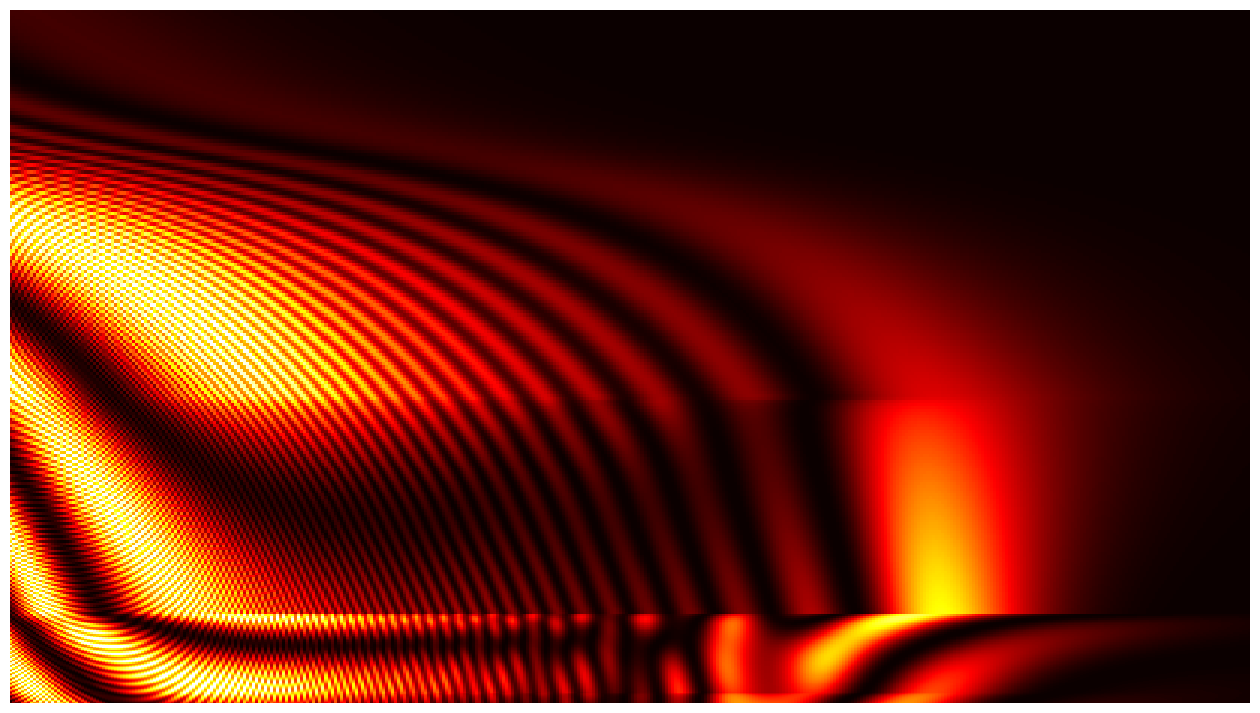

In [146]:
plt.figure(figsize=(16, 9))

plt.pcolormesh(E_grid, np.cos(Thetaz_grid), Probas_NH, cmap='hot', vmin=0, vmax=0.6, rasterized=True)

plt.xlim([0.1, 30])
plt.ylim([-1, 0.26])
plt.xscale('log')
plt.gca().axis("off")

plt.savefig('atm_osc_16:9.pdf', bbox_inches='tight', pad_inches=0)
plt.show()

/home/mathieu-ferey/miniconda3/envs/physics_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


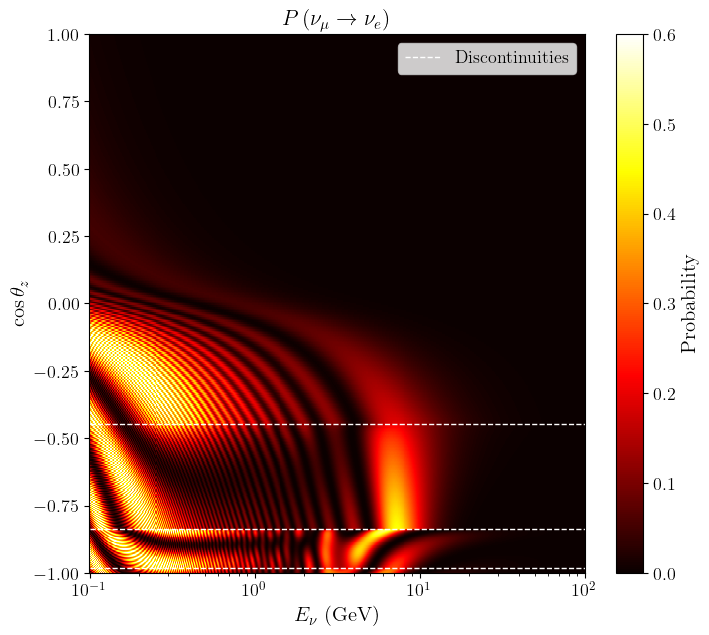

In [147]:
plt.figure(figsize=(8, 7))

plt.pcolormesh(E_grid, np.cos(Thetaz_grid), Probas_NH, cmap='hot', vmin=0, vmax=0.6, rasterized=True)

plt.gca().hlines(y=np.cos(np.pi - disc_angles), xmin=E_grid[0], xmax=E_grid[-1], color='w', ls='--', lw=1, label='Discontinuities')

plt.title(r'$P\left(\nu_\mu \rightarrow \nu_e\right)$')
plt.xlabel(r'$E_\nu$ (GeV)')
plt.ylabel(r'$\cos\theta_z$')
plt.xscale('log')
plt.colorbar(label='Probability')

plt.legend()
plt.show()

## 2 flavour oscillations validity

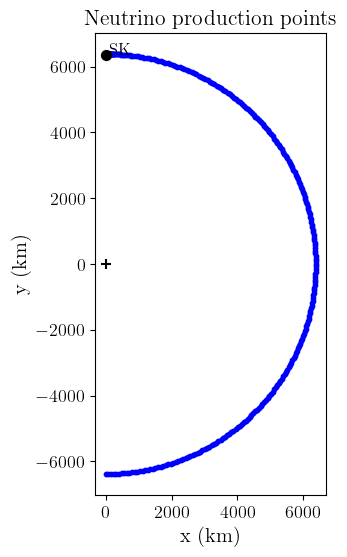

In [148]:
EE = np.logspace(-1, 2, 500)*u.GeV
Thetaz = np.linspace(0, np.pi, 500)
L = np.zeros(len(Thetaz))*u.km

plt.figure()

for i, thetaz in enumerate(Thetaz):
    xA, yA = 0, RSK

    if thetaz == 0:
        xB, yB = 0, RP
    else :
        xB, yB = RP + 100, RSK + (RP + 100)/np.tan(thetaz)

    XP, YP = find_intersections(xA, yA, xB, yB, [RP])[0]
    XSK, YSK = 0, RSK

    L[i] = np.sqrt((XP - XSK)**2 + (YP - YSK)**2)*u.km

    plt.scatter(XP, YP, color='b', s=10)

plt.scatter(XSK, YSK, color='k', s=50)
plt.text(XSK+100, YSK, 'SK', fontsize=12)
plt.scatter(0, 0, color='k', marker="+", s=50)

plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('x (km)')
plt.ylabel('y (km)')
plt.title('Neutrino production points')

plt.show()



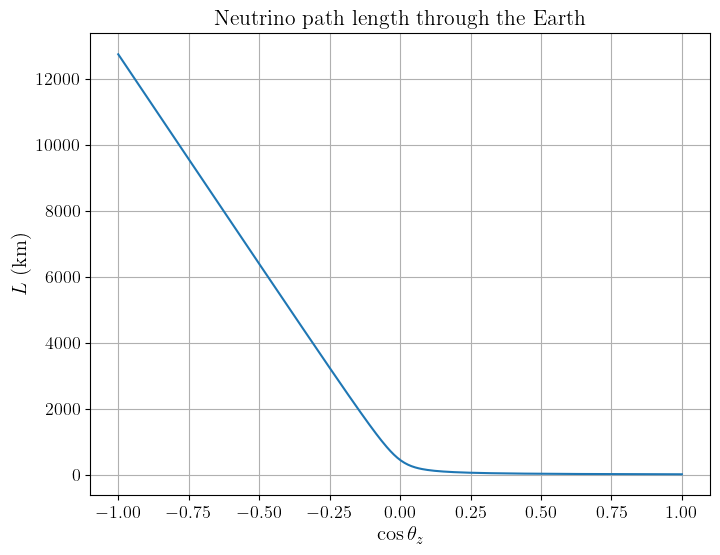

In [149]:
plt.figure()

plt.plot(np.cos(Thetaz), L)
plt.xlabel(r'$\cos\theta_z$')
plt.ylabel(r'$L$ (km)')
plt.title('Neutrino path length through the Earth')
plt.grid()
plt.show()

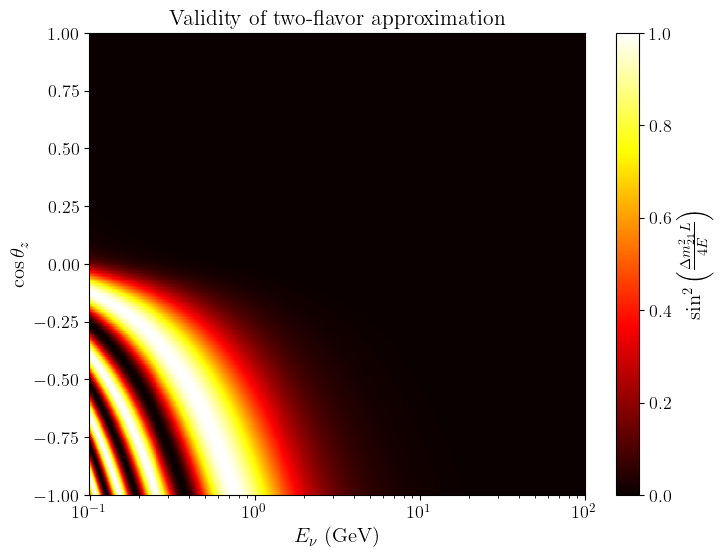

In [150]:
dm2_21 = osc.dm21

# compare dm2_21*L/(2E) with pi to check validity of two-flavor approximation

# go to 2D grid
E_grid, L_grid = np.meshgrid(EE, L)

phase = (dm2_21 * L_grid / (4 * E_grid * const.hc)).to(u.dimensionless_unscaled) * u.rad
res = np.sin(phase)**2

plt.figure()

plt.pcolormesh(EE.value, np.cos(Thetaz), res.value, cmap='hot', vmin=0, vmax=1, rasterized=True)

plt.xscale('log')
plt.xlabel(r'$E_\nu$ (GeV)')
plt.ylabel(r'$\cos\theta_z$')
plt.title(r'Validity of two-flavor approximation')
plt.colorbar(label=r'$\sin^2\left(\frac{\Delta m^2_{21} L}{4 E}\right)$')
plt.show()





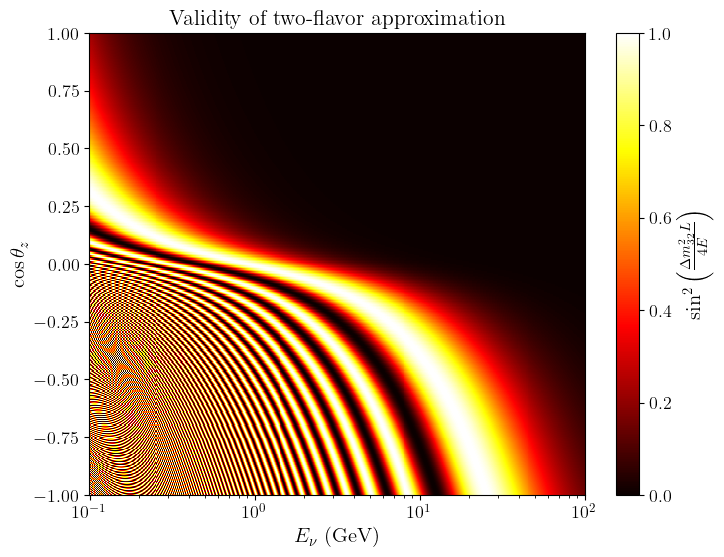

In [151]:
dm2_32 = osc.dm32


# go to 2D grid
E_grid, L_grid = np.meshgrid(EE, L)

phase = (dm2_32 * L_grid / (4 * E_grid * const.hc)).to(u.dimensionless_unscaled) * u.rad
res = np.sin(phase)**2

plt.figure()

plt.pcolormesh(EE.value, np.cos(Thetaz), res.value, cmap='hot', vmin=0, vmax=1, rasterized=True)

plt.xscale('log')
plt.xlabel(r'$E_\nu$ (GeV)')
plt.ylabel(r'$\cos\theta_z$')
plt.title(r'Validity of two-flavor approximation')
plt.colorbar(label=r'$\sin^2\left(\frac{\Delta m^2_{32} L}{4 E}\right)$')
plt.show()





In [152]:
const.hc

<Quantity 200. MeV fm>

## Different approximations

### Full 3 flavour treatment

In [ ]:
# EE = np.logspace(-1, 2, 100)*u.GeV
# Thetaz = np.linspace(0, np.pi, 100)

# Probas = {"Full": {"mu->mu": np.zeros((len(Thetaz), len(EE))), "mu->e": np.zeros((len(Thetaz), len(EE))), "e->e": np.zeros((len(Thetaz), len(EE)))},
#           "dm21=0": {"mu->mu": np.zeros((len(Thetaz), len(EE))), "mu->e": np.zeros((len(Thetaz), len(EE))), "e->e": np.zeros((len(Thetaz), len(EE)))},
#           "dm32=0": {"mu->mu": np.zeros((len(Thetaz), len(EE))), "mu->e": np.zeros((len(Thetaz), len(EE))), "e->e": np.zeros((len(Thetaz), len(EE)))},
#           "delta_CP=0": {"mu->mu": np.zeros((len(Thetaz), len(EE))), "mu->e": np.zeros((len(Thetaz), len(EE))), "e->e": np.zeros((len(Thetaz), len(EE)))},
#           "vacuum": {"mu->mu": np.zeros((len(Thetaz), len(EE))), "mu->e": np.zeros((len(Thetaz), len(EE))), "e->e": np.zeros((len(Thetaz), len(EE)))}}

# Proba = np.zeros((len(Thetaz), len(EE)))

# psi0_mu = np.array([0, 1, 0])
# psi0_e = np.array([1, 0, 0])

# osc = OscillationParameters()


# for i, thetaz in tqdm(enumerate(Thetaz)) :
#     for j, E in enumerate(EE) :

#         # full treatment
#         osc = OscillationParameters()
        
#         proba_mu = proba_through_earth(thetaz, E, layers, radii, RP, RSK, psi0_mu, osc, const, anti=False)
#         #proba_e = proba_through_earth(thetaz, E, layers, radii, RP, RSK, psi0_e, osc, const, anti=False)

#         Probas['Full']['mu->mu'][i,j] = np.abs(proba_mu[1])**2
#         Probas['Full']['mu->e'][i,j] = np.abs(proba_mu[0])**2
#         #Probas['Full']['e->e'][i,j] = np.abs(proba_e[0])**2

#         # dm21 = 0

#         osc = OscillationParameters()
#         osc.dm21 = 0*u.eV**2

#         proba_mu = proba_through_earth(thetaz, E, layers, radii, RP, RSK, psi0_mu, osc, const, anti=False)
#         #proba_e = proba_through_earth(thetaz, E, layers, radii, RP, RSK, psi0_e, osc, const, anti=False)

#         Probas['dm21=0']['mu->mu'][i,j] = np.abs(proba_mu[1])**2
#         Probas['dm21=0']['mu->e'][i,j] = np.abs(proba_mu[0])**2
#         #Probas['dm21=0']['e->e'][i,j] = np.abs(proba_e[0])**2
        
#         # dm32 = 0

#         osc = OscillationParameters()
#         osc.dm32 = 0*u.eV**2

#         proba_mu = proba_through_earth(thetaz, E, layers, radii, RP, RSK, psi0_mu, osc, const, anti=False)
#         #proba_e = proba_through_earth(thetaz, E, layers, radii, RP, RSK, psi0_e, osc, const, anti=False)

#         Probas['dm32=0']['mu->mu'][i,j] = np.abs(proba_mu[1])**2
#         Probas['dm32=0']['mu->e'][i,j] = np.abs(proba_mu[0])**2
#         #Probas['dm32=0']['e->e'][i,j] = np.abs(proba_e[0])**2

#         # delta_CP = 0
#         osc = OscillationParameters()
#         osc.deltaCP = 0

#         proba_mu = proba_through_earth(thetaz, E, layers, radii, RP, RSK, psi0_mu, osc, const, anti=False)
#         #proba_e = proba_through_earth(thetaz, E, layers, radii, RP, RSK, psi0_e, osc, const, anti=False)

#         Probas['delta_CP=0']['mu->mu'][i,j] = np.abs(proba_mu[1])**2
#         Probas['delta_CP=0']['mu->e'][i,j] = np.abs(proba_mu[0])**2
#         #Probas['delta_CP=0']['e->e'][i,j] = np.abs(proba_e[0])**2

#         # vacuum approximation
#         osc = OscillationParameters()
#         layers_vacuum = {'Atmosphere': {'Rmin': 6371, 'Rmax': 6371+500, 'Density': 0*u.g/u.cm**3, 'Z/A': 0.4, 'Color': 'lightblue'},
#           'Crust': {'Rmin': 5701, 'Rmax': 6371, 'Density': 0*u.g/u.cm**3, 'Z/A': 0.4, 'Color': 'green'},
#           'Mantle': {'Rmin': 3480, 'Rmax': 5701, 'Density': 0*u.g/u.cm**3, 'Z/A': 0.4, 'Color': 'sienna'},
#           'Outer Core': {'Rmin': 1220, 'Rmax': 3480, 'Density': 0*u.g/u.cm**3, 'Z/A': 0.4, 'Color': 'chocolate'},
#           'Inner Core': {'Rmin': 0, 'Rmax': 1220, 'Density': 0*u.g/u.cm**3, 'Z/A': 0.4, 'Color': 'firebrick'}}

#         proba_mu = proba_through_earth(thetaz, E, layers_vacuum, radii, RP, RSK, psi0_mu, osc, const, anti=False)
#         #proba_e = proba_through_earth(thetaz, E, layers_vacuum, radii, RP, RSK, psi0_e, osc, const, anti=False)

#         Probas['vacuum']['mu->mu'][i,j] = np.abs(proba_mu[1])**2
#         Probas['vacuum']['mu->e'][i,j] = np.abs(proba_mu[0])**2
#         #Probas['vacuum']['e->e'][i,j] = np.abs(proba_e[0])**2

100it [01:13,  1.35it/s]


In [5]:
# save proba to npz file
#np.savez('probas_comparison.npz', Probas=Probas, E=EE, Thetaz=Thetaz)

# load proba from npz file
data = np.load('probas_comparison.npz', allow_pickle=True)
Probas = data['Probas'].item()
EE = data['E']
Thetaz = data['Thetaz']

In [13]:
# # interpolation
Thetaz_grid = np.linspace(Thetaz.min(), Thetaz.max(), 500)
E_grid = np.logspace(np.log10(EE.min()), np.log10(EE.max()), 500)

Probas_interp = {key: {chan: np.zeros((len(Thetaz_grid), len(E_grid))) for chan in Probas[key].keys()} for key in Probas.keys()}


for key in Probas.keys() :
    for chan in Probas[key].keys() :
        # interpolate proba on the new grid, values must stay between 0 and 1
        interp = RectBivariateSpline(Thetaz, EE, Probas[key][chan])
        vals = interp(Thetaz_grid, E_grid)

        Probas_interp[key][chan] = np.clip(vals, 0.0, 1.0)



In [15]:
# print max of each proba for each key and channel
for key in Probas.keys() :
    for chan in Probas[key].keys() :
        print(f"{key} - {chan} : max = {Probas_interp[key][chan].max():.3f}")


Full - mu->mu : max = 1.000
Full - mu->e : max = 0.695
Full - e->e : max = 0.000
dm21=0 - mu->mu : max = 1.000
dm21=0 - mu->e : max = 0.469
dm21=0 - e->e : max = 0.000
dm32=0 - mu->mu : max = 1.000
dm32=0 - mu->e : max = 0.354
dm32=0 - e->e : max = 0.000
delta_CP=0 - mu->mu : max = 1.000
delta_CP=0 - mu->e : max = 0.697
delta_CP=0 - e->e : max = 0.000
vacuum - mu->mu : max = 1.000
vacuum - mu->e : max = 0.565
vacuum - e->e : max = 0.000


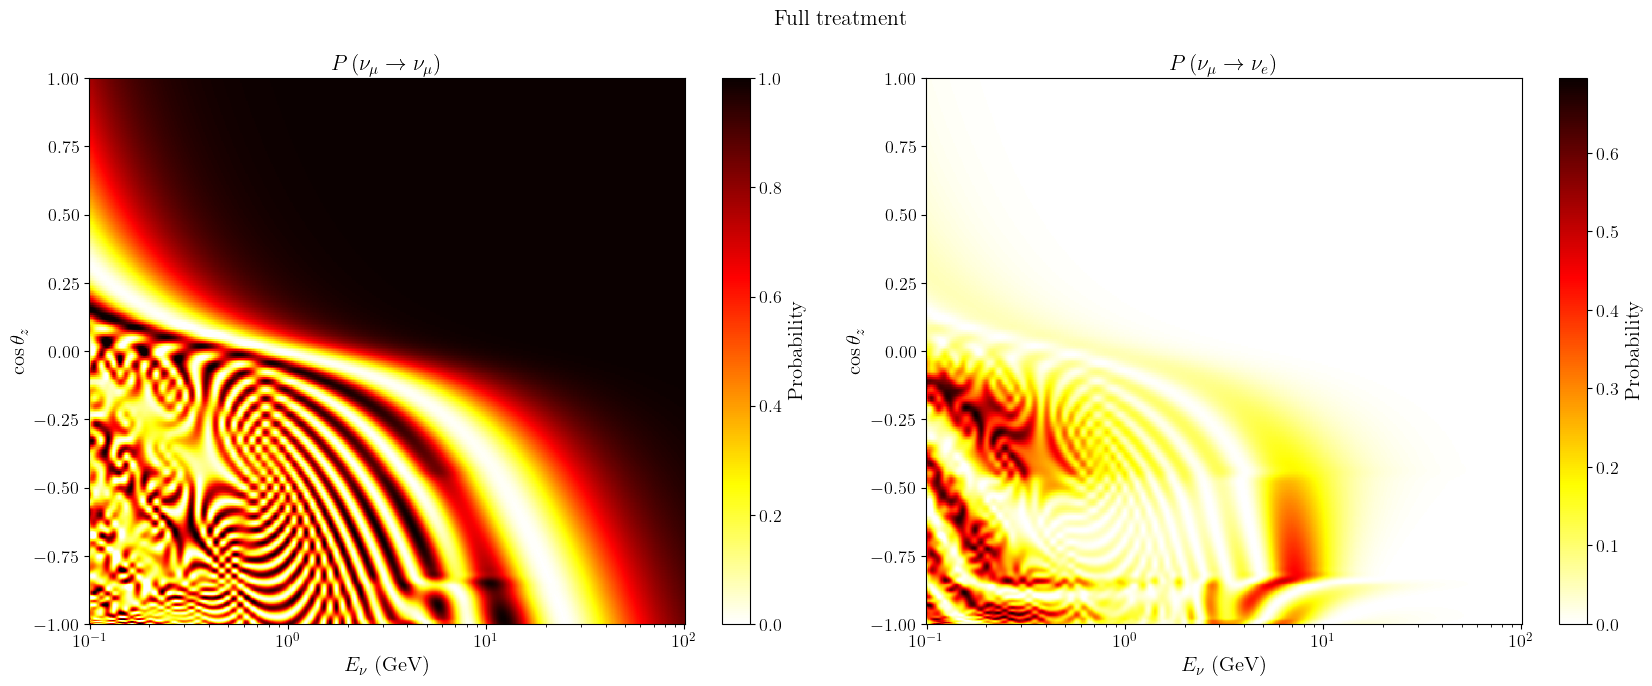

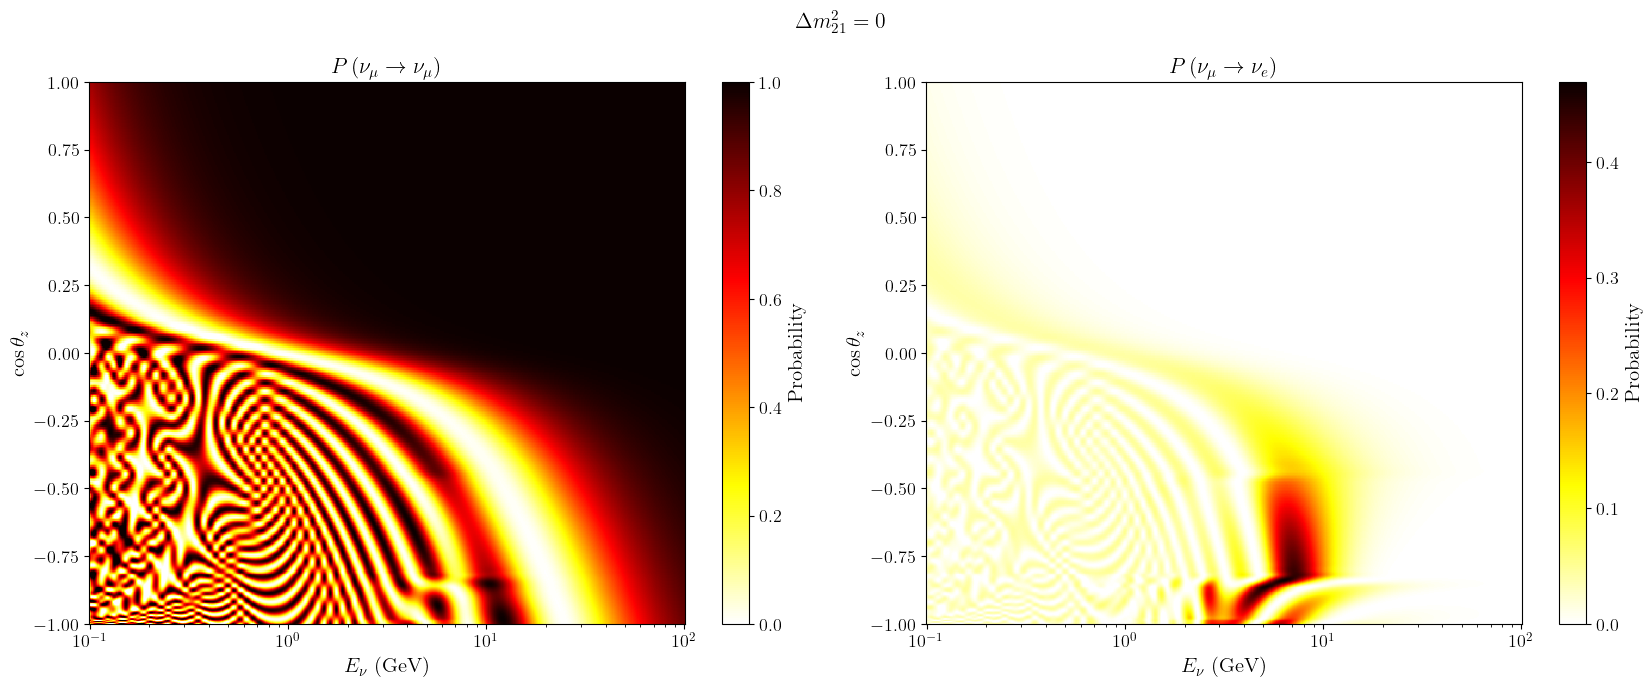

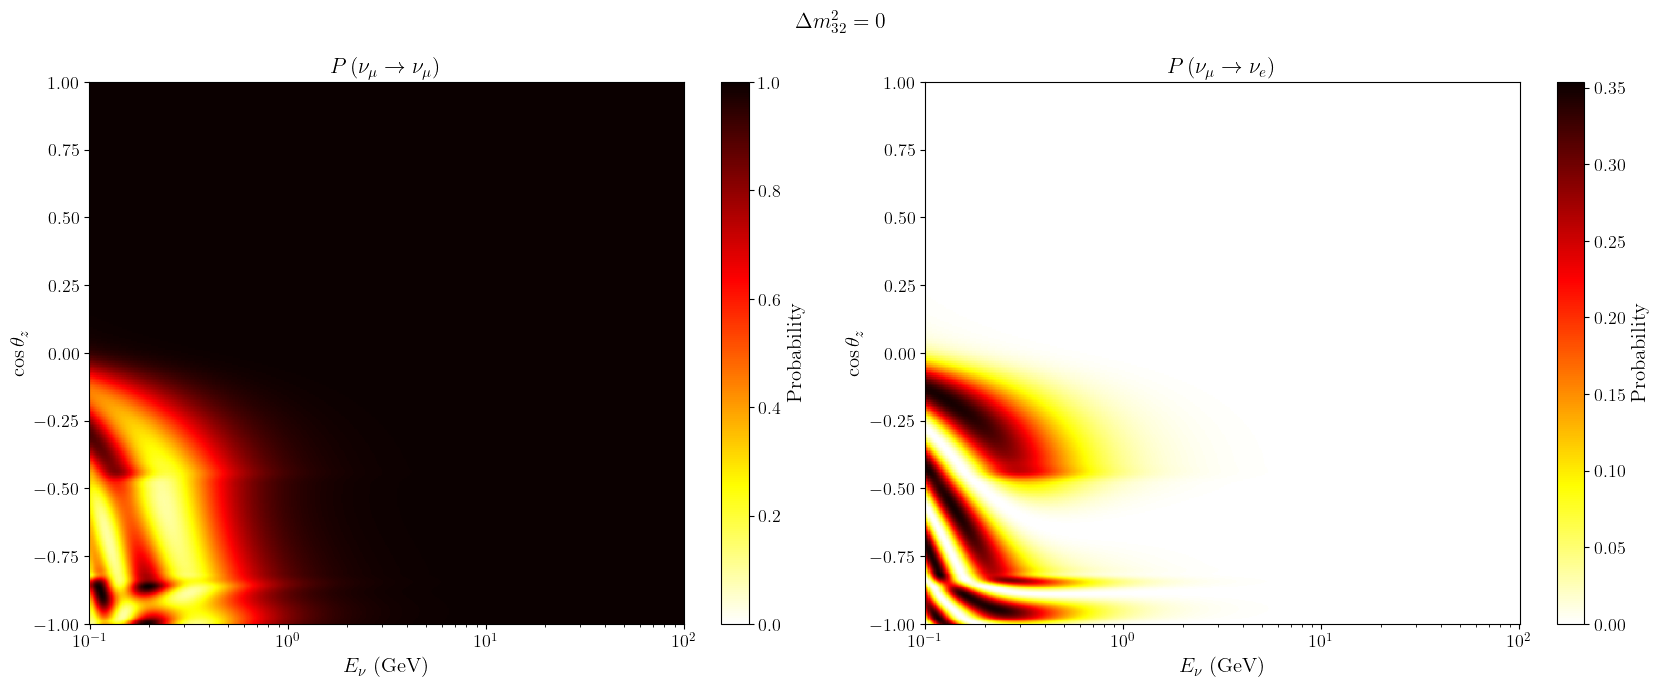

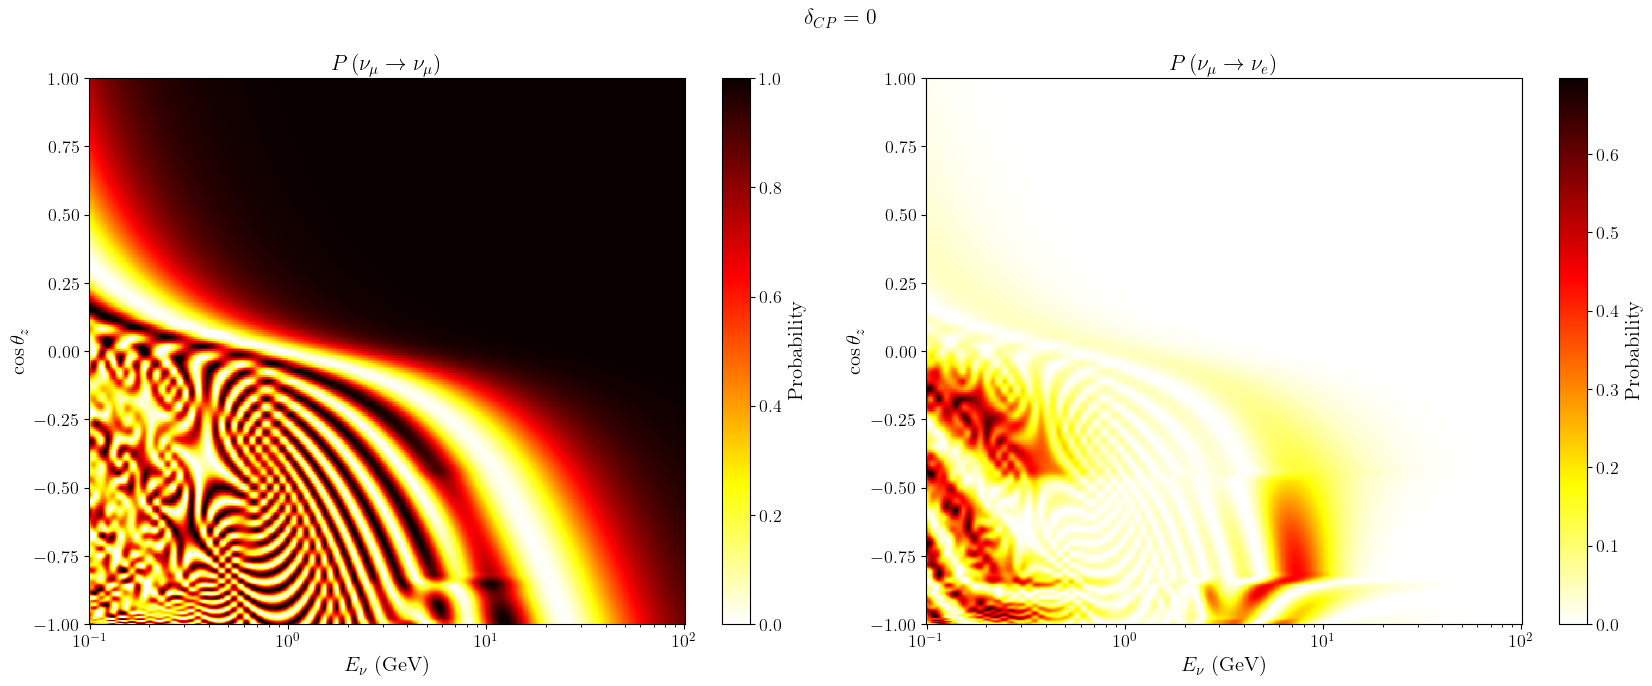

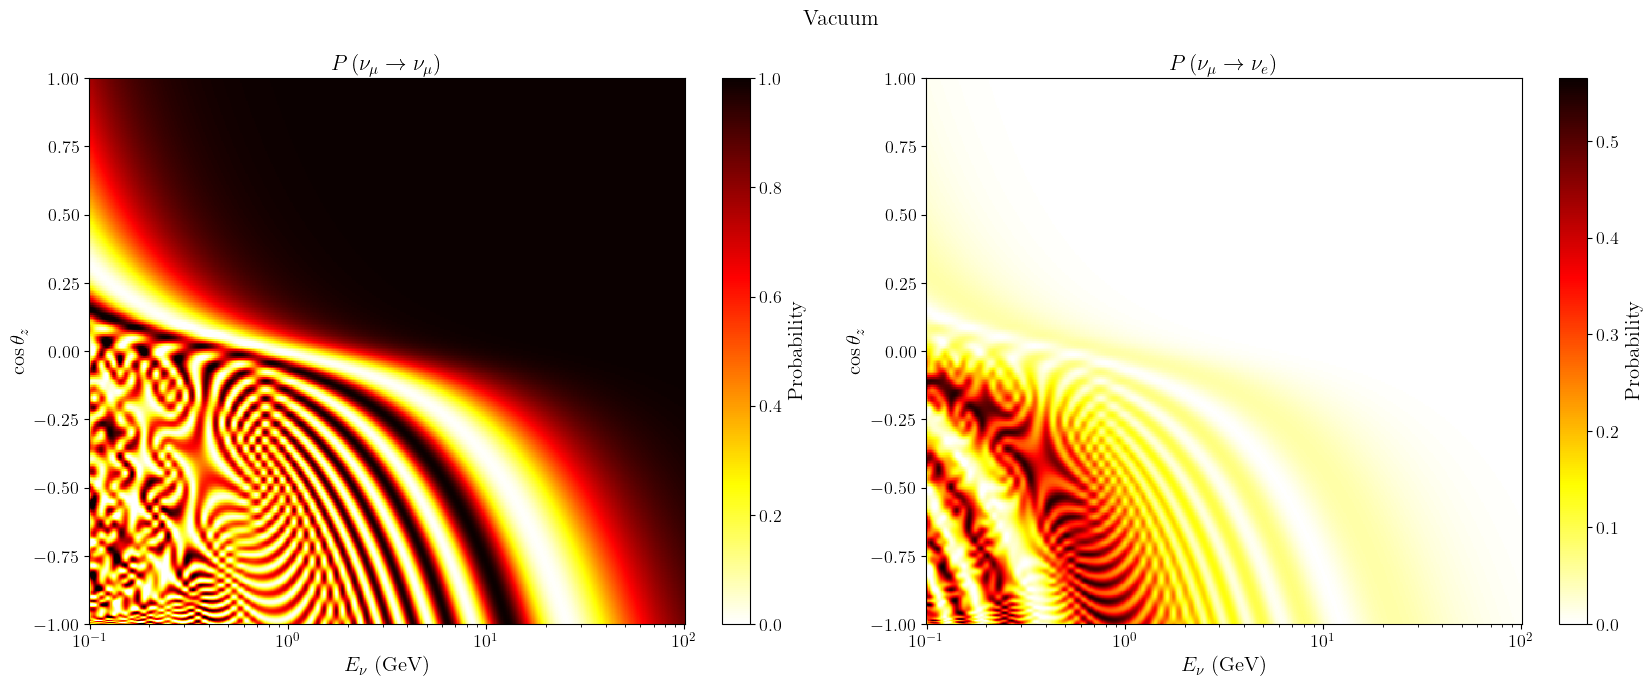

In [16]:
# ========================== Full treatment ==========================


plot_proba(E_grid, Thetaz_grid, Probas_interp['Full']['mu->mu'], Probas_interp['Full']['mu->e'], title="Full treatment")

# ================= dm21 = 0 =================

plot_proba(E_grid, Thetaz_grid, Probas_interp['dm21=0']['mu->mu'], Probas_interp['dm21=0']['mu->e'], title=r"$\Delta m_{21}^2 = 0$")

# ================= dm32 = 0 =================

plot_proba(E_grid, Thetaz_grid, Probas_interp['dm32=0']['mu->mu'], Probas_interp['dm32=0']['mu->e'], title=r"$\Delta m_{32}^2 = 0$")

# ================= delta_CP = 0 =================

plot_proba(E_grid, Thetaz_grid, Probas_interp['delta_CP=0']['mu->mu'], Probas_interp['delta_CP=0']['mu->e'], title=r"$\delta_{CP} = 0$")

# =================== Vacuum approximation =================

plot_proba(E_grid, Thetaz_grid, Probas_interp['vacuum']['mu->mu'], Probas_interp['vacuum']['mu->e'], title="Vacuum")

plt.show()

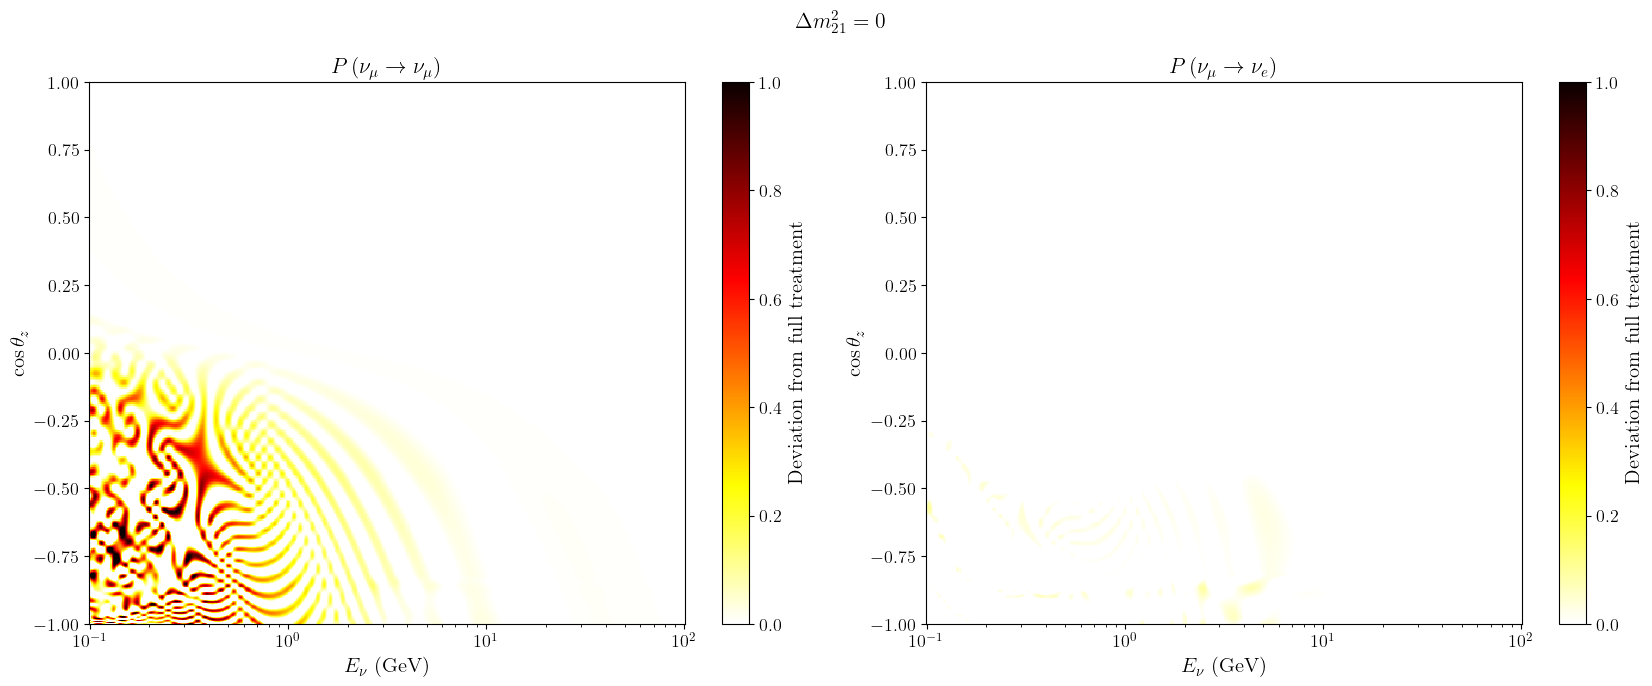

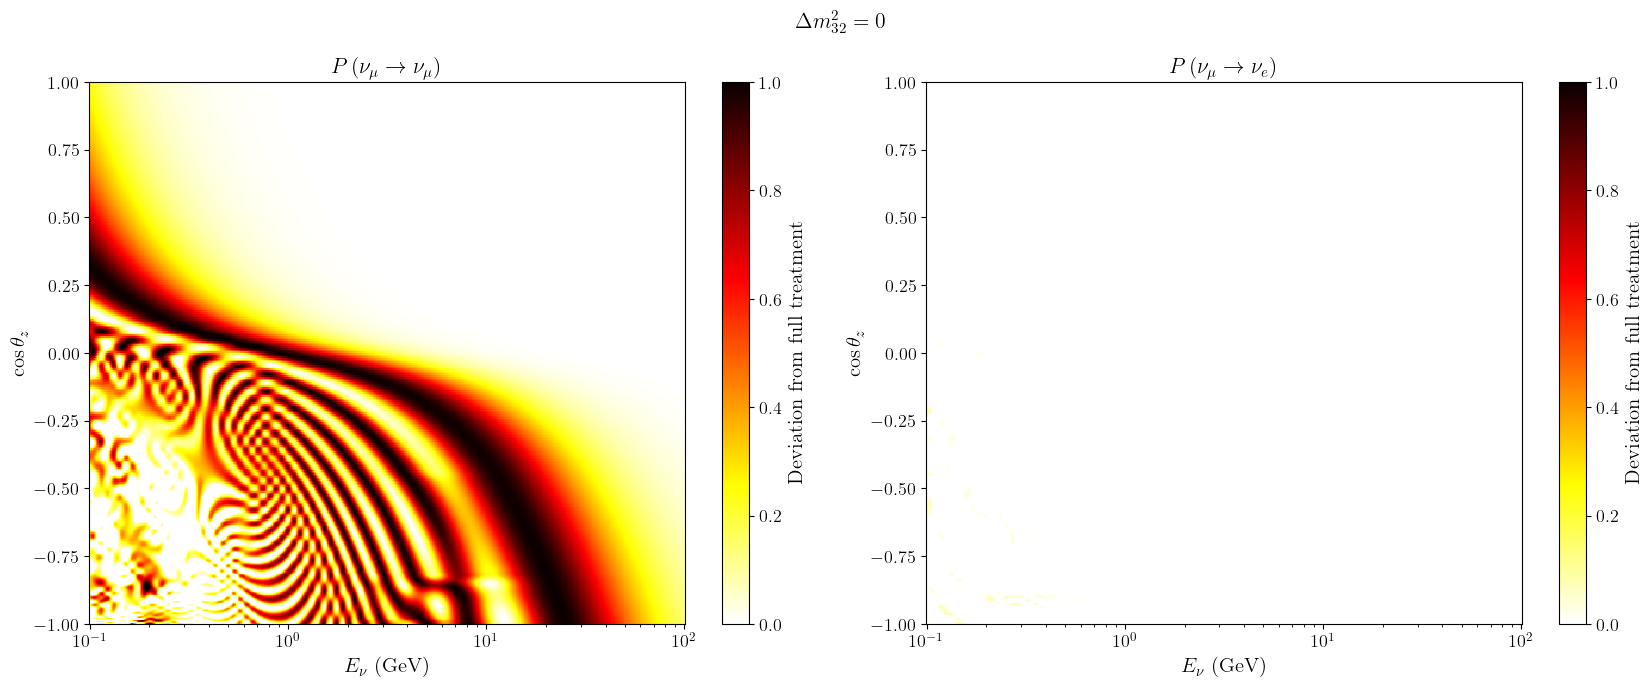

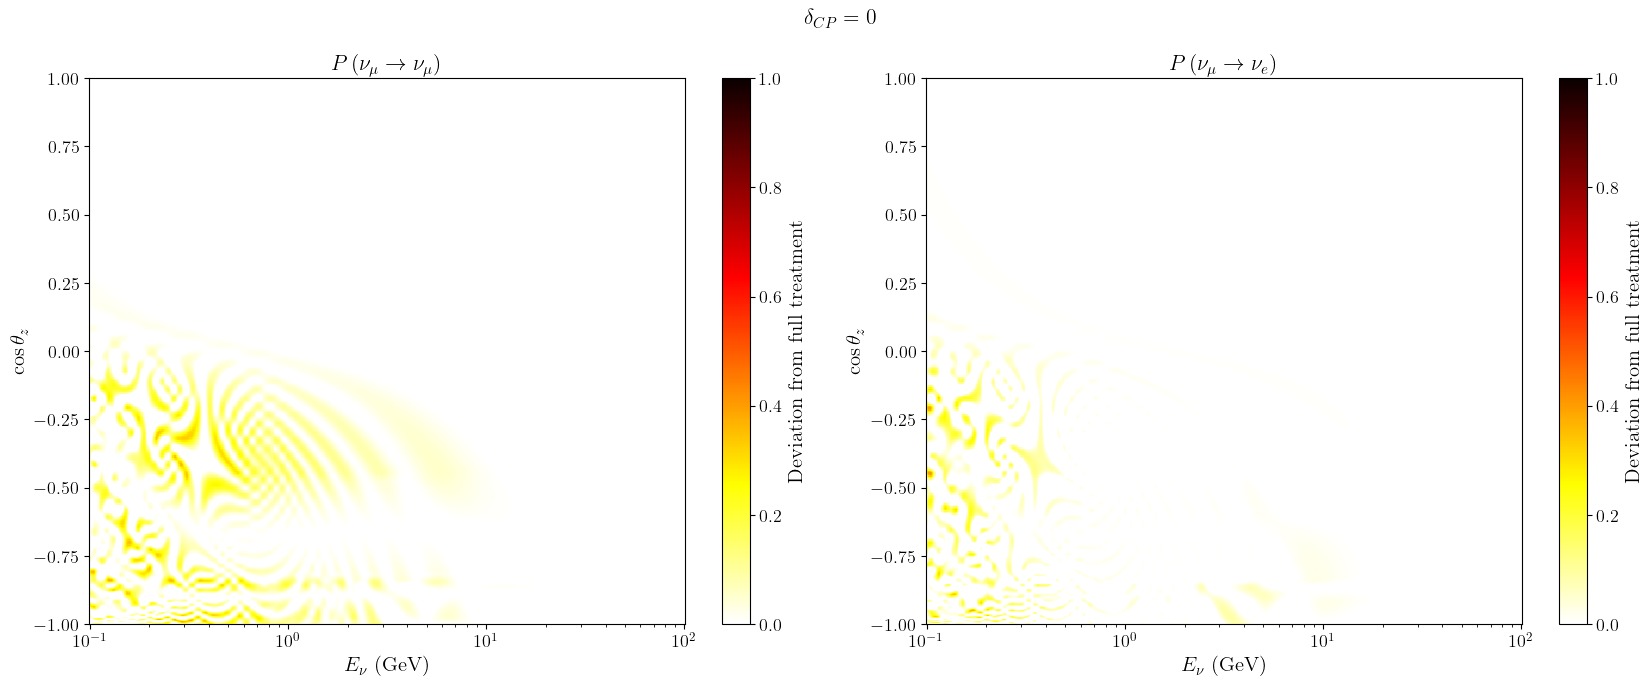

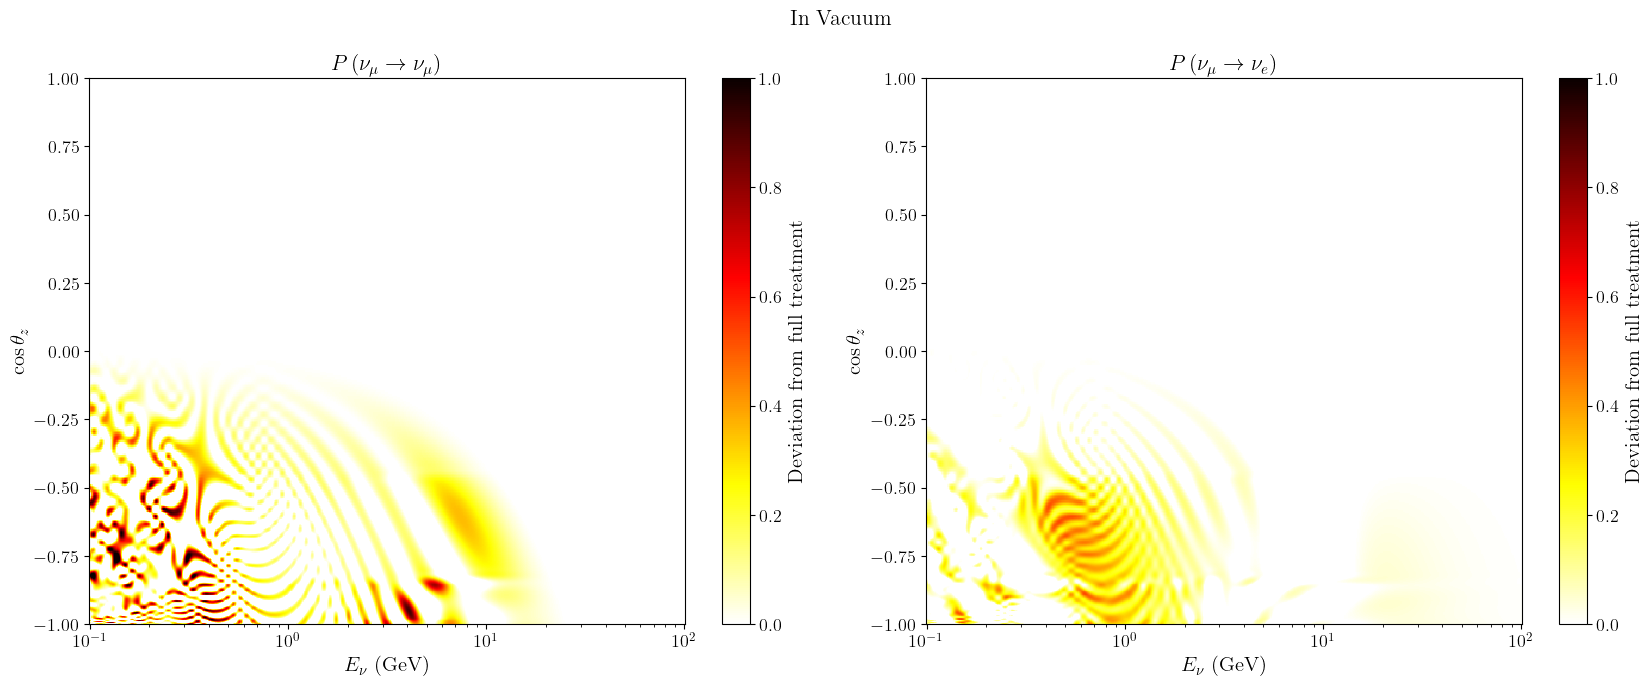

In [241]:
# Plot the difference between the full treatment and the approximations


# ================= dm21 = 0 =================

plt.figure(figsize=(17, 7))

# plot P(nu_mu -> nu_mu)
plt.subplot(1, 2, 1)
plt.pcolormesh(E_grid, np.cos(Thetaz_grid), Probas_interp['dm21=0']['mu->mu'] - Probas_interp['Full']['mu->mu'], cmap='hot_r', vmin=0, vmax=1, rasterized=True)
plt.title(r'$P\left(\nu_\mu \rightarrow \nu_\mu\right)$')
plt.xlabel(r'$E_\nu$ (GeV)')
plt.ylabel(r'$\cos\theta_z$')
plt.xscale('log')
plt.colorbar(label='Deviation from full treatment')

# plot P(nu_mu -> nu_e)
plt.subplot(1, 2, 2)
plt.pcolormesh(E_grid, np.cos(Thetaz_grid), Probas_interp['dm21=0']['mu->e'] - Probas_interp['Full']['mu->e'], cmap='hot_r', vmin=0, vmax=1, rasterized=True)
plt.title(r'$P\left(\nu_\mu \rightarrow \nu_e\right)$')
plt.xlabel(r'$E_\nu$ (GeV)')
plt.ylabel(r'$\cos\theta_z$')
plt.xscale('log')
plt.colorbar(label='Deviation from full treatment')

plt.suptitle(r"$\Delta m_{21}^2 = 0$")

plt.tight_layout()

# ================= dm32 = 0 =================

plt.figure(figsize=(17, 7))

# plot P(nu_mu -> nu_mu)
plt.subplot(1, 2, 1)
plt.pcolormesh(E_grid, np.cos(Thetaz_grid), Probas_interp['dm32=0']['mu->mu'] - Probas_interp['Full']['mu->mu'], cmap='hot_r', vmin=0, vmax=1, rasterized=True)
plt.title(r'$P\left(\nu_\mu \rightarrow \nu_\mu\right)$')
plt.xlabel(r'$E_\nu$ (GeV)')
plt.ylabel(r'$\cos\theta_z$')
plt.xscale('log')
plt.colorbar(label='Deviation from full treatment')

# plot P(nu_mu -> nu_e)
plt.subplot(1, 2, 2)
plt.pcolormesh(E_grid, np.cos(Thetaz_grid), Probas_interp['dm32=0']['mu->e'] - Probas_interp['Full']['mu->e'], cmap='hot_r', vmin=0, vmax=1, rasterized=True)
plt.title(r'$P\left(\nu_\mu \rightarrow \nu_e\right)$')
plt.xlabel(r'$E_\nu$ (GeV)')
plt.ylabel(r'$\cos\theta_z$')
plt.xscale('log')
plt.colorbar(label='Deviation from full treatment')


plt.suptitle(r"$\Delta m_{32}^2 = 0$")

plt.tight_layout()

# ================= delta_CP = 0 =================

plt.figure(figsize=(17, 7))

# plot P(nu_mu -> nu_mu)
plt.subplot(1, 2, 1)
plt.pcolormesh(E_grid, np.cos(Thetaz_grid), Probas_interp['delta_CP=0']['mu->mu'] - Probas_interp['Full']['mu->mu'], cmap='hot_r', vmin=0, vmax=1, rasterized=True)
plt.title(r'$P\left(\nu_\mu \rightarrow \nu_\mu\right)$')
plt.xlabel(r'$E_\nu$ (GeV)')
plt.ylabel(r'$\cos\theta_z$')
plt.xscale('log')
plt.colorbar(label='Deviation from full treatment')

# plot P(nu_mu -> nu_e)
plt.subplot(1, 2, 2)
plt.pcolormesh(E_grid, np.cos(Thetaz_grid), Probas_interp['delta_CP=0']['mu->e'] - Probas_interp['Full']['mu->e'], cmap='hot_r', vmin=0, vmax=1, rasterized=True)
plt.title(r'$P\left(\nu_\mu \rightarrow \nu_e\right)$')
plt.xlabel(r'$E_\nu$ (GeV)')
plt.ylabel(r'$\cos\theta_z$')
plt.xscale('log')
plt.colorbar(label='Deviation from full treatment')

plt.suptitle(r"$\delta_{CP} = 0$")

plt.tight_layout()

# =================== Vacuum approximation =================

plt.figure(figsize=(17, 7))

# plot P(nu_mu -> nu_mu)
plt.subplot(1, 2, 1)
plt.pcolormesh(E_grid, np.cos(Thetaz_grid), Probas_interp['vacuum']['mu->mu'] - Probas_interp['Full']['mu->mu'], cmap='hot_r', vmin=0, vmax=1, rasterized=True)
plt.title(r'$P\left(\nu_\mu \rightarrow \nu_\mu\right)$')
plt.xlabel(r'$E_\nu$ (GeV)')
plt.ylabel(r'$\cos\theta_z$')
plt.xscale('log')
plt.colorbar(label='Deviation from full treatment')   

# plot P(nu_mu -> nu_e)
plt.subplot(1, 2, 2)
plt.pcolormesh(E_grid, np.cos(Thetaz_grid), Probas_interp['vacuum']['mu->e'] - Probas_interp['Full']['mu->e'], cmap='hot_r', vmin=0, vmax=1, rasterized=True)
plt.title(r'$P\left(\nu_\mu \rightarrow \nu_e\right)$')
plt.xlabel(r'$E_\nu$ (GeV)')
plt.ylabel(r'$\cos\theta_z$')
plt.xscale('log')
plt.colorbar(label='Deviation from full treatment')


plt.suptitle("In Vacuum")
plt.tight_layout()

plt.show()


### 2 flavour approximation

In [188]:
EE = np.logspace(-1, 2, 100)*u.GeV
Thetaz = np.linspace(0, np.pi, 100)
L = np.zeros(len(Thetaz))*u.km

for i, thetaz in enumerate(Thetaz):
    xA, yA = 0, RSK

    if thetaz == 0:
        xB, yB = 0, RP
    else :
        xB, yB = RP + 100, RSK + (RP + 100)/np.tan(thetaz)

    XP, YP = find_intersections(xA, yA, xB, yB, [RP])[0]
    XSK, YSK = 0, RSK

    L[i] = np.sqrt((XP - XSK)**2 + (YP - YSK)**2)*u.km

In [189]:
E_grid, L_grid = np.meshgrid(EE, L)

t13 = np.arcsin(np.sqrt(osc.sin213))
phase = 1.27*osc.dm32.value * L_grid.value / (E_grid.value)

Probas["mu->mu"] = 1 - 4*np.cos(t13)**2 * osc.sin223 * (1 - np.cos(t13)**2 * osc.sin223) * np.sin(phase)**2
Probas["mu->e"] = osc.sin223*np.sin(2*t13)**2 * np.sin(phase)**2
Probas["e->e"] = 1 - np.sin(2*t13)**2 * np.sin(phase)**2

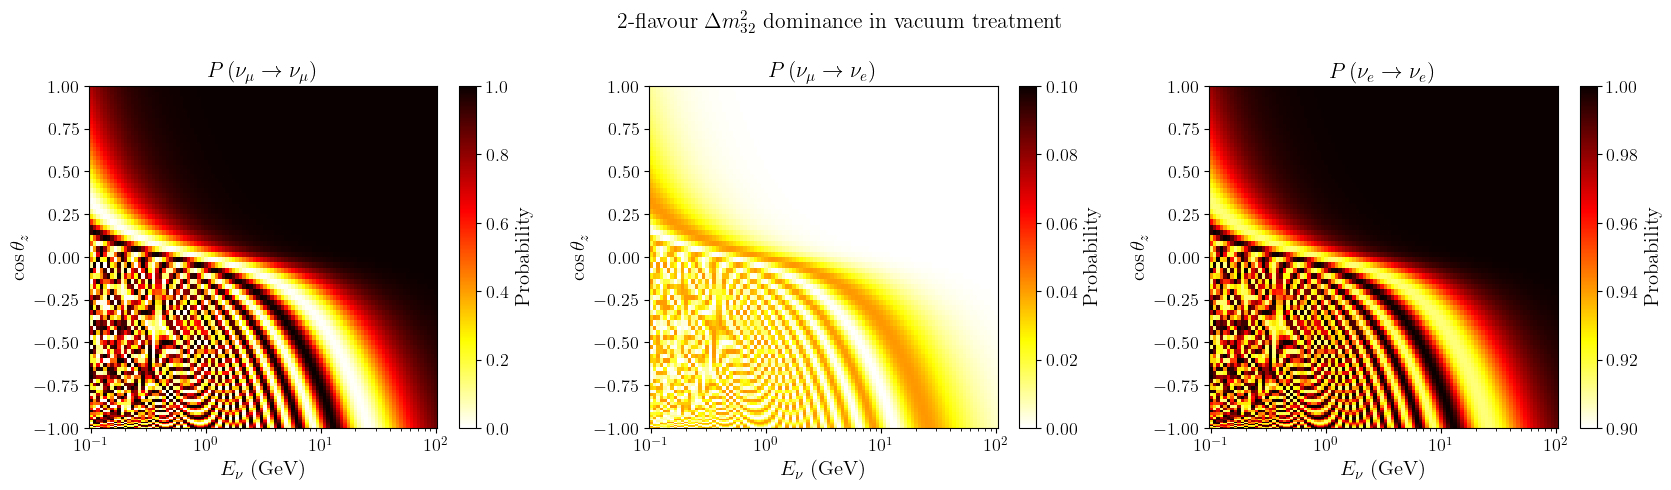

In [190]:
plt.figure(figsize=(17, 5))

# plot P(nu_mu -> nu_mu)
plt.subplot(1, 3, 1)
plt.pcolormesh(EE.value, np.cos(Thetaz), Probas["mu->mu"], cmap='hot_r', vmin=0, vmax=1, rasterized=True)
plt.title(r'$P\left(\nu_\mu \rightarrow \nu_\mu\right)$')
plt.xlabel(r'$E_\nu$ (GeV)')
plt.ylabel(r'$\cos\theta_z$')
plt.xscale('log')
plt.colorbar(label='Probability')

# plot P(nu_mu -> nu_e)
plt.subplot(1, 3, 2)
plt.pcolormesh(EE.value, np.cos(Thetaz), Probas["mu->e"], cmap='hot_r', vmin=0, vmax=0.1, rasterized=True)
plt.title(r'$P\left(\nu_\mu \rightarrow \nu_e\right)$')
plt.xlabel(r'$E_\nu$ (GeV)')
plt.ylabel(r'$\cos\theta_z$')
plt.xscale('log')
plt.colorbar(label='Probability')

# plot P(nu_e -> nu_e)
plt.subplot(1, 3, 3)
plt.pcolormesh(EE.value, np.cos(Thetaz), Probas["e->e"], cmap='hot_r', vmin=0.9, vmax=1, rasterized=True)
plt.title(r'$P\left(\nu_e \rightarrow \nu_e\right)$')
plt.xlabel(r'$E_\nu$ (GeV)')
plt.ylabel(r'$\cos\theta_z$')
plt.xscale('log')
plt.colorbar(label='Probability')

plt.suptitle(r"2-flavour $\Delta m^2_{32}$ dominance in vacuum treatment")

plt.tight_layout()
plt.show()

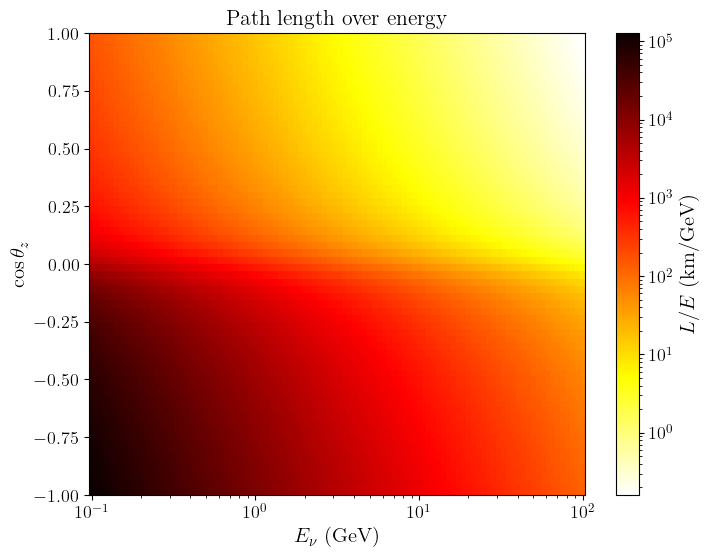

In [207]:
plt.figure()

plt.pcolormesh(EE.value, np.cos(Thetaz), L_grid.value/E_grid.value, cmap='hot_r', rasterized=True, norm=LogNorm())

plt.xscale('log')
plt.xlabel(r'$E_\nu$ (GeV)')
plt.ylabel(r'$\cos\theta_z$')
plt.title(r'Path length over energy')
plt.colorbar(label=r'$L/E$ (km/GeV)')
plt.show()

ValueError: x and y must have same first dimension, but have shapes (100, 100) and (10000,)

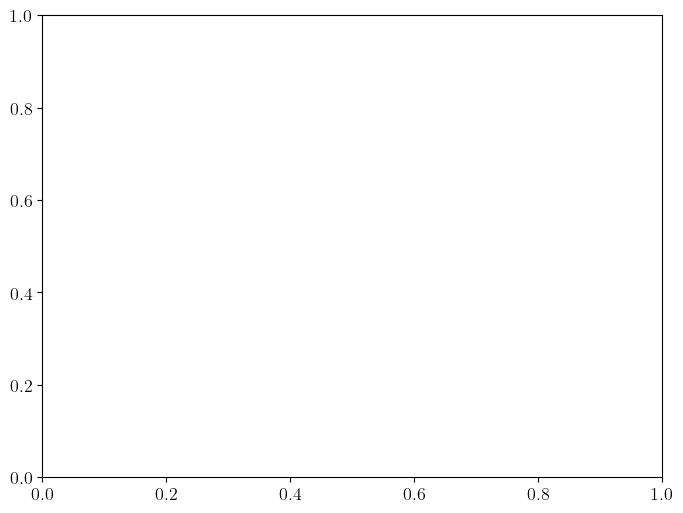

In [208]:
# Project mu->mu probability onto L/E axis

plt.figure()

plt.plot(L_grid.value/E_grid.value, Probas["mu->mu"].flatten(), '.', markersize=1, alpha=0.5)
plt.xscale('log')
plt.xlabel(r'$L/E$ (km/GeV)')
plt.ylabel(r'$P\left(\nu_\mu \rightarrow \nu_\mu\right)$')
plt.title(r'Projection of $P\left(\nu_\mu \rightarrow \nu_\mu\right)$ onto $L/E$ axis')
plt.grid()
plt.show()

In [202]:
np.min(L_grid.value/E_grid.value)

0.16

In [203]:
np.max(L_grid.value/E_grid.value)

127560.0